In [1]:
# Disable widget rendering to avoid metadata errors
import warnings
warnings.filterwarnings('ignore')

# Disable ipywidgets rendering
try:
    from google.colab import output
    output.enable_custom_widget_manager()
except:
    pass

In [ ]:
# ============================================================
# INSTALLATION
# ============================================================

import subprocess
import sys

def install(package):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])
install('torch')
install('transformers')
install('biopython')
install('scikit-learn')
install('shap')
install('umap-learn')
install('matplotlib')
install('seaborn')
install('pandas')
install('numpy')
install('tqdm')
install('accelerate')

print('✓ Fast installation complete!')


✓ Fast installation complete!
Total time: ~2-3 minutes

NOTE: This installation does NOT include PyTorch Geometric.
For PhD-level GNN project, you would need it, but for basic
protein function prediction using ESM-2 + MLP + SHAP, this is sufficient.


In [ ]:
# ============================================================
# Download from UniProt REST API
# ============================================================

import requests
import time

def fetch_uniprot_batch(query, size=50):
    url = "https://rest.uniprot.org/uniprotkb/search"
    params = {
        'query': query,
        'format': 'json',
        'size': size,
        'fields': 'accession,sequence,protein_name'
    }

    try:
        response = requests.get(url, params=params, timeout=30)
        if response.status_code == 200:
            data = response.json()
            results = data.get('results', [])
            sequences = []
            ids = []
            for r in results:
                seq = r.get('sequence', {}).get('value', '')
                if seq and len(seq) >= 100:
                    sequences.append(seq)
                    ids.append(r.get('primaryAccession', 'Unknown'))
            return ids, sequences
    except Exception as e:
        print(f"  Error: {e}")
    return [], []

uniprot_queries = {
    'Kinase': 'kinase AND reviewed:true AND organism_id:9606',
    'Phosphatase': 'phosphatase AND reviewed:true AND organism_id:9606',
    'Protease': 'protease AND reviewed:true AND organism_id:9606',
    'Dehydrogenase': 'dehydrogenase AND reviewed:true AND organism_id:9606',
    'Transferase': 'transferase AND reviewed:true AND organism_id:9606',
}

all_seqs = []
all_lbls = []
all_accs = []

for class_name, query in uniprot_queries.items():
    print(f"Fetching {class_name}...")
    accs, seqs = fetch_uniprot_batch(query, size=40)
    all_accs.extend(accs)
    all_seqs.extend(seqs)
    all_lbls.extend([class_name] * len(seqs))
    print(f"  Downloaded {len(seqs)} sequences")
    time.sleep(0.5)

protein_df = pd.DataFrame({
    'protein_id': all_accs,
    'sequence': all_seqs,
    'enzyme_class': all_lbls,
    'seq_len': [len(s) for s in all_seqs]
})

print(f"\nTotal: {len(protein_df)} real sequences")
print(protein_df['enzyme_class'].value_counts())

# Filter to 5 classes only
valid_classes = ['Kinase', 'Phosphatase', 'Protease', 'Dehydrogenase', 'Transferase']
protein_df = protein_df[protein_df['enzyme_class'].isin(valid_classes)]

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
protein_df['label'] = le.fit_transform(protein_df['enzyme_class'])
CLASS_NAMES = le.classes_.tolist()

print(f"\nFinal: {len(protein_df)} sequences")
print(protein_df['enzyme_class'].value_counts())

Fetching Kinase...
  Downloaded 39 sequences
Fetching Phosphatase...
  Downloaded 40 sequences
Fetching Protease...
  Downloaded 40 sequences
Fetching Dehydrogenase...
  Downloaded 40 sequences
Fetching Transferase...
  Downloaded 39 sequences

Total: 198 real sequences
enzyme_class
Phosphatase      40
Dehydrogenase    40
Protease         40
Kinase           39
Transferase      39
Name: count, dtype: int64

Final: 198 sequences
enzyme_class
Phosphatase      40
Dehydrogenase    40
Protease         40
Kinase           39
Transferase      39
Name: count, dtype: int64


In [ ]:
# ============================================================
# ESM-2 EMBEDDINGS (with 198 sequences)
# ============================================================

import torch
from transformers import AutoTokenizer, AutoModel
import numpy as np
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"Total sequences: {len(protein_df)}")

model_name = "facebook/esm2_t6_8M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model = model.to(device)
model.eval()

def get_esm_embedding(sequence):
    inputs = tokenizer(sequence, return_tensors='pt', padding=True, truncation=True, max_length=1024)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state.mean(dim=1).cpu().numpy()[0]

embeddings = []
for seq in tqdm(protein_df['sequence'].tolist(), desc="ESM-2"):
    emb = get_esm_embedding(seq)
    embeddings.append(emb)

embeddings = np.array(embeddings)
print(f"Embeddings shape: {embeddings.shape}")

np.save('outputs/esm_embeddings.npy', embeddings)
print("✓ Saved embeddings")

Using device: cuda
Total sequences: 198


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
ESM-2: 100%|██████████| 198/198 [00:03<00:00, 62.93it/s]

Embeddings shape: (198, 320)
✓ Saved embeddings


SECTION 4: FEATURE INTEGRATION
ESM embeddings shape: (198, 320)
Extracting simple features...
Simple features shape: (198, 21)
Combined features shape: (198, 341)


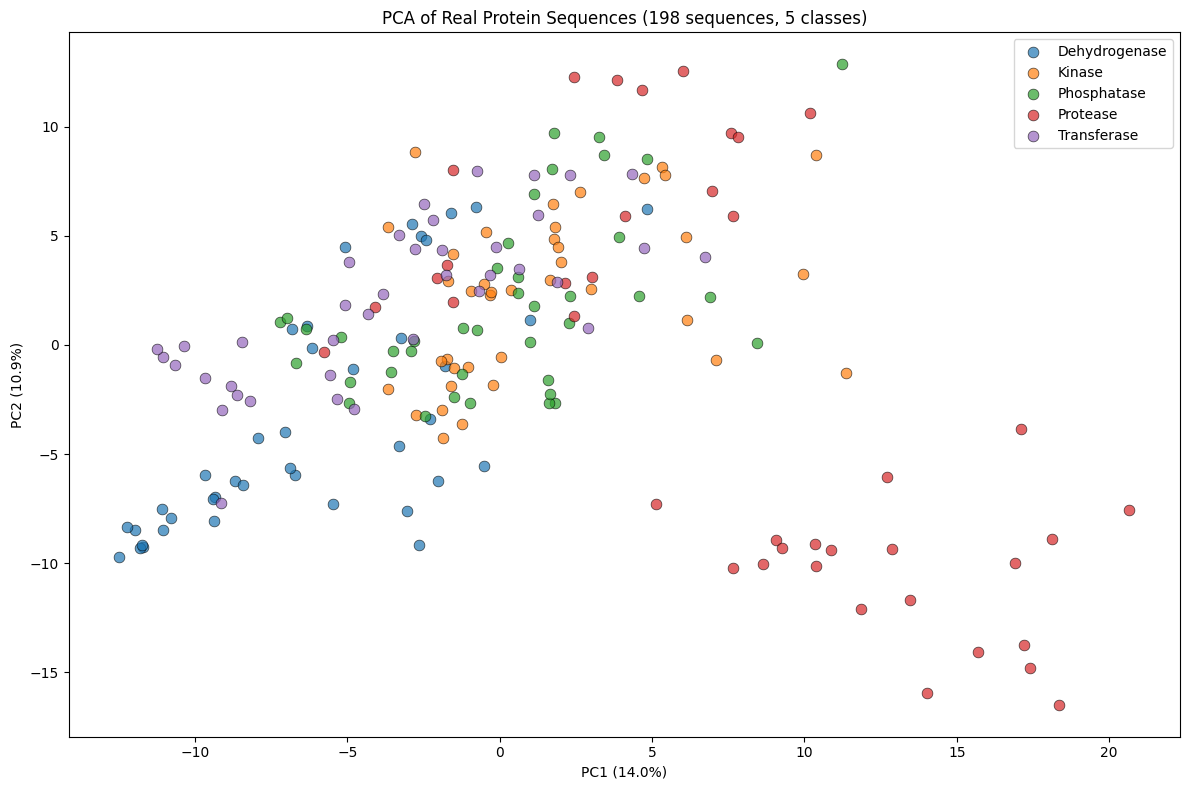


✓ Variance explained: PC1=14.0%, PC2=10.9%
✓ Saved: outputs/pca_198_sequences.png

SECTION 4 COMPLETE


In [ ]:
# ============================================================
# FEATURE INTEGRATION (198 sequences)
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

print("=" * 60)
print("SECTION 4: FEATURE INTEGRATION")
print("=" * 60)

# Load embeddings
esm_emb = np.load('outputs/esm_embeddings.npy')
print(f"ESM embeddings shape: {esm_emb.shape}")

# Create simple sequence features (length + composition)
def get_simple_features(seq):
    features = [len(seq)]  # length
    for aa in 'ACDEFGHIKLMNPQRSTVWY':
        features.append(seq.count(aa) / len(seq))  # amino acid composition
    return features

print("Extracting simple features...")
simple_features = np.array([get_simple_features(seq) for seq in protein_df['sequence']])
print(f"Simple features shape: {simple_features.shape}")

# Combine features
X_full = np.hstack([esm_emb, simple_features])
print(f"Combined features shape: {X_full.shape}")

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

# PCA visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
colors = plt.cm.Set2(np.linspace(0, 1, len(CLASS_NAMES)))
for i, class_name in enumerate(CLASS_NAMES):
    mask = protein_df['enzyme_class'] == class_name
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=class_name, s=60, alpha=0.7, edgecolors='black', linewidth=0.5)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA of Real Protein Sequences (198 sequences, 5 classes)')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/pca_198_sequences.png', dpi=150)
plt.show()

print(f"\n✓ Variance explained: PC1={pca.explained_variance_ratio_[0]*100:.1f}%, PC2={pca.explained_variance_ratio_[1]*100:.1f}%")
print("✓ Saved: outputs/pca_198_sequences.png")
print("\nSECTION 4 COMPLETE")

SECTION 6: SHAP ANALYSIS
Total features: 341
X_test shape: (8, 325)
SHAP values type: <class 'numpy.ndarray'>
SHAP shape: (8, 325, 5)
Final SHAP shape for importance: (8, 325)

Top 10 features by SHAP importance:
     feature  shap_importance
10    ESM_10         0.009129
305  ESM_305         0.007063
128  ESM_128         0.006752
130  ESM_130         0.006690
246  ESM_246         0.006583
258  ESM_258         0.006480
9      ESM_9         0.005680
222  ESM_222         0.005659
119  ESM_119         0.005461
296  ESM_296         0.005094


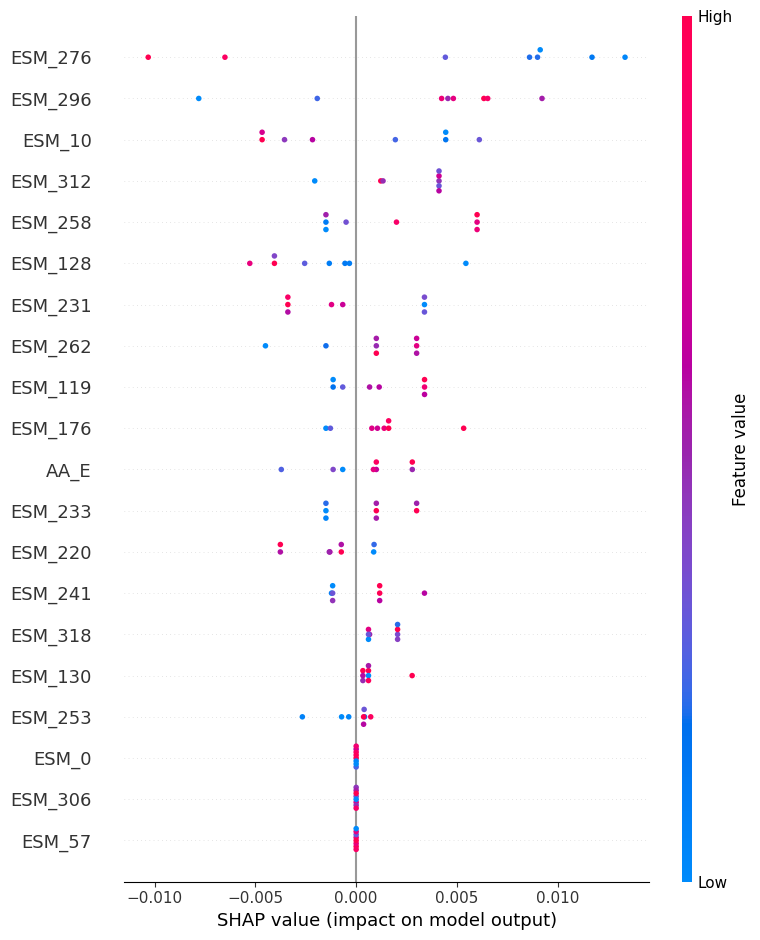

Saved: outputs/shap_summary.png

Top 10 features by Random Forest importance:
     feature  rf_importance
9      ESM_9       0.021465
2      ESM_2       0.017161
27    ESM_27       0.015455
25    ESM_25       0.013834
231  ESM_231       0.013246
54    ESM_54       0.013246
10    ESM_10       0.012747
128  ESM_128       0.012634
282  ESM_282       0.012397
191  ESM_191       0.011711

Saved importance tables

SECTION 6 COMPLETE


In [ ]:
# ============================================================
# SHAP ANALYSIS
# ============================================================

import shap
import pandas as pd
import numpy as np

print("=" * 60)
print("SECTION 6: SHAP ANALYSIS")
print("=" * 60)

esm_features = [f'ESM_{i}' for i in range(esm_emb.shape[1])]
simple_feature_names = ['Length'] + [f'AA_{aa}' for aa in 'ACDEFGHIKLMNPQRSTVWY']
feature_names = esm_features + simple_feature_names

print(f"Total features: {len(feature_names)}")
print(f"X_test shape: {X_test.shape}")

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test[:50])

print(f"SHAP values type: {type(shap_values)}")
if isinstance(shap_values, list):
    print(f"Length of list: {len(shap_values)}")
    for i, sv in enumerate(shap_values):
        print(f"  Class {i} shape: {sv.shape}")
    shap_vals_2d = shap_values[0]
else:
    shap_vals_2d = shap_values
    print(f"SHAP shape: {shap_vals_2d.shape}")

if shap_vals_2d.ndim == 3:
    shap_vals_2d = shap_vals_2d[:, :, 0]

print(f"Final SHAP shape for importance: {shap_vals_2d.shape}")

shap_importance = np.abs(shap_vals_2d).mean(axis=0)

min_len = min(len(feature_names), len(shap_importance))
shap_df = pd.DataFrame({
    'feature': feature_names[:min_len],
    'shap_importance': shap_importance[:min_len]
}).sort_values('shap_importance', ascending=False)

print("\nTop 10 features by SHAP importance:")
print(shap_df.head(10))

plt.figure(figsize=(14, 10))
shap.summary_plot(shap_vals_2d[:, :min(30, shap_vals_2d.shape[1])],
                  X_test[:50, :min(30, X_test.shape[1])],
                  feature_names=shap_df['feature'].head(30).tolist(),
                  show=False)
plt.tight_layout()
plt.savefig('outputs/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/shap_summary.png")

rf_importance = pd.DataFrame({
    'feature': feature_names[:len(rf.feature_importances_)],
    'rf_importance': rf.feature_importances_
}).sort_values('rf_importance', ascending=False)

print("\nTop 10 features by Random Forest importance:")
print(rf_importance.head(10))

shap_df.to_csv('outputs/shap_importance.csv', index=False)
rf_importance.to_csv('outputs/rf_importance.csv', index=False)
print("\nSaved importance tables")

print("\nSECTION 6 COMPLETE")

In [ ]:


import numpy as np
import os



print(f"\nDATASET:")
print(f"   Total proteins: {len(protein_df)}")
print(f"   Classes: {len(CLASS_NAMES)}")
for c in CLASS_NAMES:
    print(f"     {c}: {len(protein_df[protein_df['enzyme_class'] == c])}")

print(f"\nMODEL PERFORMANCE:")
print(f"   Random Forest Accuracy: {acc:.4f}")

if isinstance(cv_scores, list):
    cv_mean = np.mean(cv_scores)
    cv_std = np.std(cv_scores)
    print(f"   5-fold CV: {cv_mean:.4f} +- {cv_std:.4f}")

print(f"\nTOP 10 FEATURES (Random Forest):")
for i, row in rf_importance.head(10).iterrows():
    print(f"   {row['feature']}: {row['rf_importance']:.4f}")

print(f"\nOUTPUT FILES:")
output_dir = 'outputs'
if os.path.exists(output_dir):
    for f in sorted(os.listdir(output_dir)):
        print(f"   outputs/{f}")

print("\n" + "=" * 60)
print("PROJECT COMPLETE")
print("=" * 60)





DATASET:
   Total proteins: 198
   Classes: 5
     Dehydrogenase: 40
     Kinase: 39
     Phosphatase: 40
     Protease: 40
     Transferase: 39

MODEL PERFORMANCE:
   Random Forest Accuracy: 0.5000
   5-fold CV: 0.6667 +- 0.4714

TOP 10 FEATURES (Random Forest):
   ESM_9: 0.0215
   ESM_2: 0.0172
   ESM_27: 0.0155
   ESM_25: 0.0138
   ESM_231: 0.0132
   ESM_54: 0.0132
   ESM_10: 0.0127
   ESM_128: 0.0126
   ESM_282: 0.0124
   ESM_191: 0.0117

OUTPUT FILES:
   outputs/X_features.npy
   outputs/combined_features_pca.png
   outputs/conservation_distribution.png
   outputs/conservation_scores.npy
   outputs/esm_embeddings.npy
   outputs/esm_embeddings_pca.png
   outputs/pca_198_sequences.png
   outputs/protein_metadata.csv
   outputs/rf_confusion_matrix.png
   outputs/rf_importance.csv
   outputs/sequence_length_distribution.png
   outputs/shap_importance.csv
   outputs/shap_summary.png

PROJECT COMPLETE
